# Audio Enhancement Pipeline

A reusable signal lab for podcast enhancement using spectral DSP and optional ML.

## Goals
- Load raw podcast WAV
- Visualize signal in time and frequency domains
- Remove noise and improve clarity
- Compare before and after outputs
- Export enhanced audio

In [2]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import librosa
import librosa.display
import soundfile as sf

try:
    import torch
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

print(f'Torch available: {TORCH_AVAILABLE}')

Torch available: True


In [4]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == 'audio_visuals':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'audio_visuals' / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'audio_visuals' / 'outputs'

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

AUDIO_PATH = DATA_DIR / 'audio_enhancement_data.wav'
OUTPUT_PATH = OUTPUT_DIR / 'enhanced_podcast.wav'

TARGET_SR = 22050
SEGMENT_SECONDS = 2.0
OVERLAP = 0.5

USE_ML = False
PLOT_DEBUG = True
GENERATE_SYNTHETIC_INPUT = False

VALIDATION_SWEEPS = [
    {'segment_seconds': 1.0, 'overlap': 0.25},
    {'segment_seconds': 2.0, 'overlap': 0.50},
    {'segment_seconds': 4.0, 'overlap': 0.50},
]

print('Audio path:', AUDIO_PATH)
print('Output path:', OUTPUT_PATH)

Audio path: c:\Users\Windows User\NMR-Project\audio_visuals\data\audio_enhancement_data.wav
Output path: c:\Users\Windows User\NMR-Project\audio_visuals\outputs\enhanced_podcast.wav


In [5]:
def generate_synthetic_podcast_clip(sr=22050, duration_sec=30.0):
    t = np.linspace(0.0, duration_sec, int(sr * duration_sec), endpoint=False)

    # Speech-like harmonic carrier with slow amplitude envelope
    f0 = 130.0 + 25.0 * np.sin(2.0 * np.pi * 0.35 * t)
    phase = 2.0 * np.pi * np.cumsum(f0) / sr
    speech = (
        0.35 * np.sin(phase)
        + 0.18 * np.sin(2.0 * phase + 0.2)
        + 0.08 * np.sin(3.0 * phase + 0.5)
    )

    envelope = 0.55 + 0.45 * np.maximum(0.0, np.sin(2.0 * np.pi * 1.9 * t))
    speech *= envelope

    # Add common podcast noise sources
    hum = 0.012 * np.sin(2.0 * np.pi * 60.0 * t)
    hiss = 0.01 * np.random.normal(0.0, 1.0, t.shape[0])
    low_rumble = 0.008 * np.sin(2.0 * np.pi * 28.0 * t)

    signal_mix = speech + hum + hiss + low_rumble
    signal_mix = signal_mix / (np.max(np.abs(signal_mix)) + 1e-12)
    return signal_mix.astype(np.float32)

if not AUDIO_PATH.exists() and GENERATE_SYNTHETIC_INPUT:
    synthetic_audio = generate_synthetic_podcast_clip(sr=TARGET_SR, duration_sec=35.0)
    sf.write(AUDIO_PATH, synthetic_audio, TARGET_SR)
    print('Wrote synthetic input WAV to', AUDIO_PATH)
elif not AUDIO_PATH.exists():
    raise FileNotFoundError(f'Input file not found: {AUDIO_PATH}. Set GENERATE_SYNTHETIC_INPUT=True to create a test clip.')

audio, sr = librosa.load(str(AUDIO_PATH), sr=TARGET_SR, mono=True)
duration = len(audio) / sr
rms = float(np.sqrt(np.mean(audio ** 2)))
peak = float(np.max(np.abs(audio)))

print(f'Sample rate: {sr}')
print(f'Duration: {duration:.2f} sec')
print(f'RMS: {rms:.4f}')
print(f'Peak: {peak:.4f}')

Sample rate: 22050
Duration: 21.28 sec
RMS: 0.0738
Peak: 0.5422


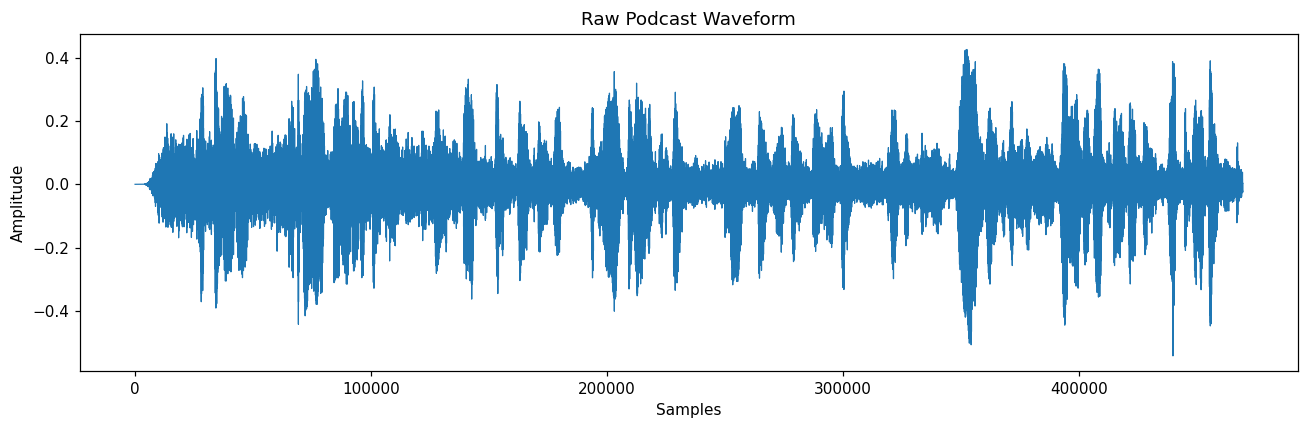

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(audio, linewidth=0.8)
plt.title('Raw Podcast Waveform')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

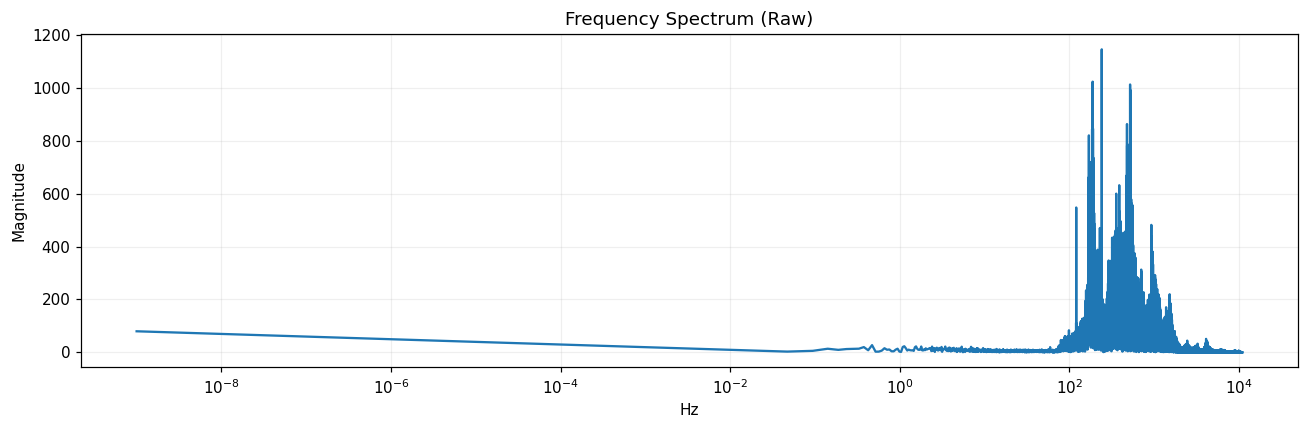

In [7]:
def compute_fft_magnitude(x, sr):
    fft_vals = np.fft.rfft(x)
    fft_freq = np.fft.rfftfreq(len(x), 1.0 / sr)
    return fft_freq, np.abs(fft_vals)

fft_freq_raw, fft_mag_raw = compute_fft_magnitude(audio, sr)

plt.figure(figsize=(12, 4))
plt.semilogx(fft_freq_raw + 1e-9, fft_mag_raw, label='Raw')
plt.title('Frequency Spectrum (Raw)')
plt.xlabel('Hz')
plt.ylabel('Magnitude')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

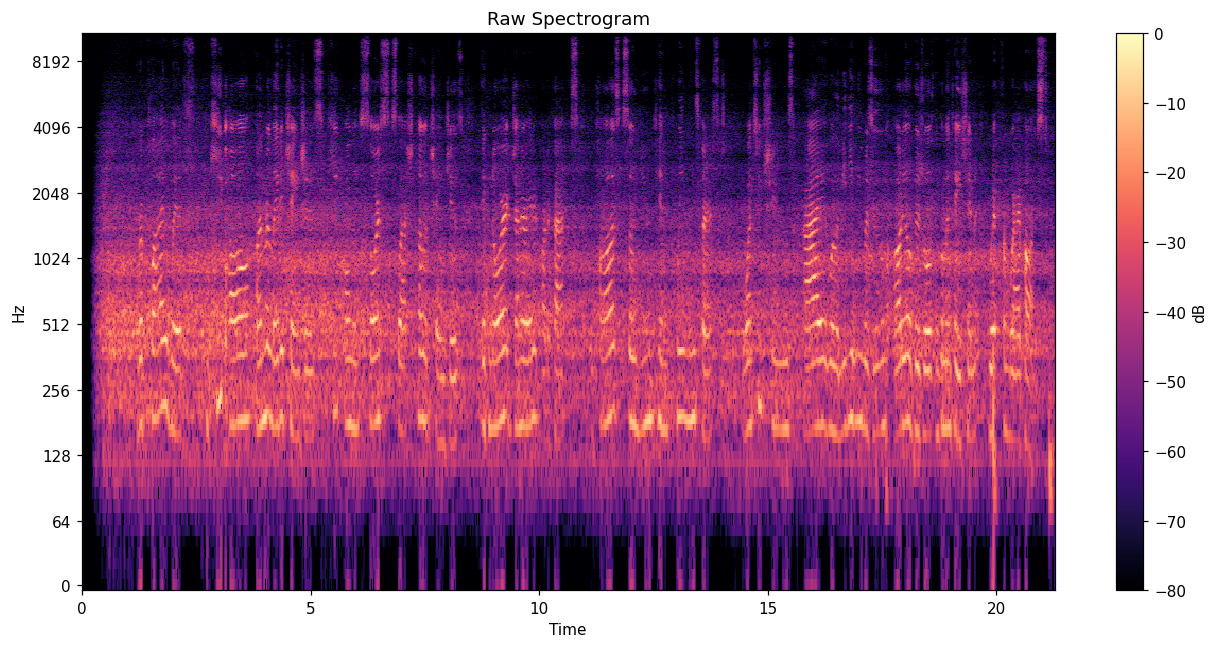

In [8]:
S_raw = np.abs(librosa.stft(audio, n_fft=2048, hop_length=512))
S_raw_db = librosa.amplitude_to_db(S_raw, ref=np.max)

plt.figure(figsize=(12, 6))
librosa.display.specshow(S_raw_db, sr=sr, hop_length=512, x_axis='time', y_axis='log')
plt.colorbar(label='dB')
plt.title('Raw Spectrogram')
plt.tight_layout()
plt.show()

In [9]:
def segment_audio(x, sr, segment_seconds, overlap):
    segment_len = int(segment_seconds * sr)
    hop_len = int(max(1, segment_len * (1.0 - overlap)))

    if len(x) < segment_len:
        padded = np.zeros(segment_len, dtype=np.float32)
        padded[:len(x)] = x
        return np.expand_dims(padded, axis=0), hop_len

    segments = []
    for start in range(0, len(x) - segment_len + 1, hop_len):
        segments.append(x[start:start + segment_len])

    tail = (len(x) - segment_len) % hop_len
    if tail != 0:
        last = np.zeros(segment_len, dtype=np.float32)
        remainder = x[-segment_len:]
        last[:len(remainder)] = remainder
        segments.append(last)

    return np.asarray(segments, dtype=np.float32), hop_len

def overlap_add(segments, hop_len):
    seg_len = segments.shape[1]
    out_len = hop_len * (len(segments) - 1) + seg_len
    out = np.zeros(out_len, dtype=np.float32)
    weight = np.zeros(out_len, dtype=np.float32)

    window = np.hanning(seg_len).astype(np.float32)
    window[window < 1e-6] = 1e-6

    for idx, seg in enumerate(segments):
        start = idx * hop_len
        out[start:start + seg_len] += seg * window
        weight[start:start + seg_len] += window

    out = out / np.maximum(weight, 1e-6)
    return out

segments, hop_len = segment_audio(audio, sr, SEGMENT_SECONDS, OVERLAP)
print('Segments shape:', segments.shape)
print('Hop length:', hop_len)

Segments shape: (21, 44100)
Hop length: 22050


In [10]:
def highpass_filter(x, sr, cutoff=80.0, order=4):
    b, a = signal.butter(order, cutoff / (sr / 2.0), btype='highpass')
    return signal.filtfilt(b, a, x).astype(np.float32)

def spectral_subtract(x, sr, n_fft=1024, hop_length=256, noise_quantile=0.2, reduction=1.0):
    stft = librosa.stft(x, n_fft=n_fft, hop_length=hop_length)
    mag = np.abs(stft)
    phase = np.angle(stft)

    frame_energy = np.mean(mag, axis=0)
    quiet_thresh = np.quantile(frame_energy, noise_quantile)
    quiet_mask = frame_energy <= quiet_thresh

    if np.any(quiet_mask):
        noise_profile = np.median(mag[:, quiet_mask], axis=1, keepdims=True)
    else:
        noise_profile = np.median(mag, axis=1, keepdims=True)

    cleaned_mag = np.maximum(mag - reduction * noise_profile, 0.0)
    cleaned = cleaned_mag * np.exp(1j * phase)
    y = librosa.istft(cleaned, hop_length=hop_length, length=len(x))
    return y.astype(np.float32)

def enhance_segment_classical(seg, sr):
    y = highpass_filter(seg, sr, cutoff=80.0, order=4)
    y = spectral_subtract(y, sr, n_fft=1024, hop_length=256, noise_quantile=0.2, reduction=1.0)
    return y

In [11]:
ML_READY = False
ml_model = None

if USE_ML:
    try:
        from machine_learning.neural_net import DenoiseNetPhysics, build_model_from_latest

        ml_model, loaded_from = build_model_from_latest(
            checkpoints_dir=str(Path('machine_learning') / 'checkpoints')
        )
        if loaded_from is not None:
            ML_READY = True
            print('ML checkpoint loaded:', loaded_from)
        else:
            print('No suitable ML checkpoint found, fallback to classical DSP.')
    except Exception as exc:
        print('ML init failed, fallback to classical DSP:', exc)

def maybe_ml_enhance_segment(seg):
    if not (USE_ML and ML_READY and TORCH_AVAILABLE):
        return seg

    with torch.no_grad():
        seg_t = torch.from_numpy(seg.astype(np.float32))[None, None, :]
        seg_2ch = torch.cat([seg_t, torch.zeros_like(seg_t)], dim=1)
        out_2ch = ml_model(seg_2ch).cpu().numpy()[0]
        return out_2ch[0].astype(np.float32)

print('USE_ML:', USE_ML, '| ML_READY:', ML_READY)

USE_ML: False | ML_READY: False


In [12]:
def compute_metrics(x_raw, x_enh):
    eps = 1e-12
    raw_rms = float(np.sqrt(np.mean(x_raw ** 2)))
    enh_rms = float(np.sqrt(np.mean(x_enh ** 2)))

    noise_est_raw = x_raw - signal.savgol_filter(x_raw, 513, 3, mode='interp')
    noise_est_enh = x_enh - signal.savgol_filter(x_enh, 513, 3, mode='interp')

    raw_noise = float(np.sqrt(np.mean(noise_est_raw ** 2)))
    enh_noise = float(np.sqrt(np.mean(noise_est_enh ** 2)))

    snr_proxy_raw = 20.0 * math.log10((raw_rms + eps) / (raw_noise + eps))
    snr_proxy_enh = 20.0 * math.log10((enh_rms + eps) / (enh_noise + eps))

    clip_ratio = float(np.mean(np.abs(x_enh) >= 0.999))
    finite_count = int(np.isfinite(x_enh).sum())
    non_finite = int(x_enh.size - finite_count)

    return {
        'raw_rms': raw_rms,
        'enh_rms': enh_rms,
        'rms_delta_db': 20.0 * math.log10((enh_rms + eps) / (raw_rms + eps)),
        'snr_proxy_raw_db': snr_proxy_raw,
        'snr_proxy_enh_db': snr_proxy_enh,
        'snr_proxy_delta_db': snr_proxy_enh - snr_proxy_raw,
        'clip_ratio': clip_ratio,
        'non_finite_samples': non_finite,
    }

enhanced_segments = []
for seg in segments:
    seg_dsp = enhance_segment_classical(seg, sr)
    seg_ml = maybe_ml_enhance_segment(seg_dsp)
    enhanced_segments.append(seg_ml.astype(np.float32))

enhanced_segments = np.asarray(enhanced_segments, dtype=np.float32)
enhanced_audio = overlap_add(enhanced_segments, hop_len)
enhanced_audio = enhanced_audio[:len(audio)]

max_abs = float(np.max(np.abs(enhanced_audio)) + 1e-12)
if max_abs > 1.0:
    enhanced_audio = enhanced_audio / max_abs

metrics = compute_metrics(audio, enhanced_audio)
metrics_df = pd.DataFrame([metrics])
metrics_df

,raw_rms,enh_rms,rms_delta_db,snr_proxy_raw_db,snr_proxy_enh_db,snr_proxy_delta_db,clip_ratio,non_finite_samples
0,0.073825,0.063395,-1.322954,-0.08948,-0.091578,-0.002098,0.0,0


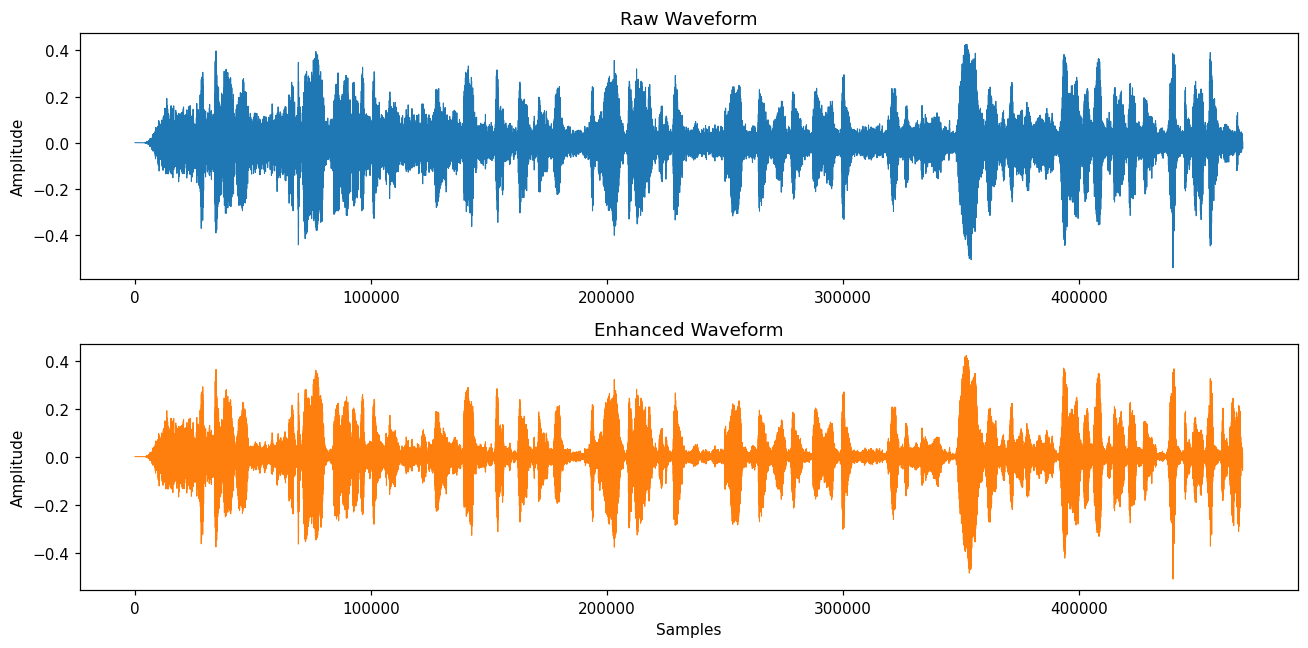

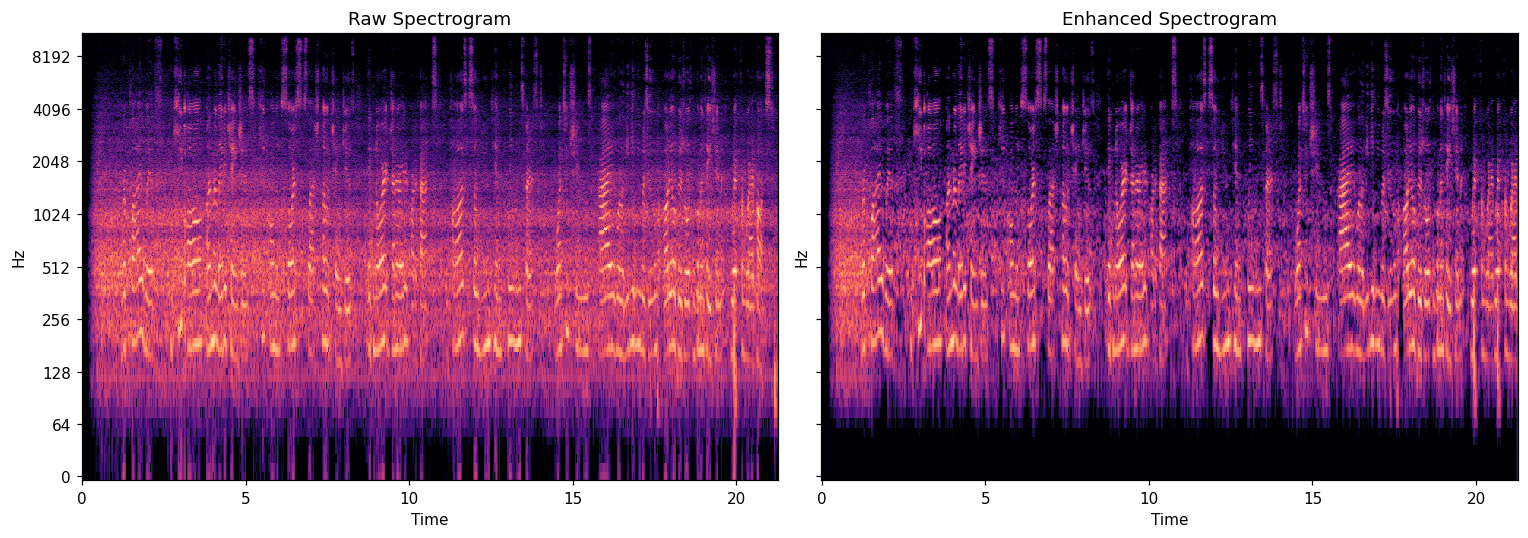

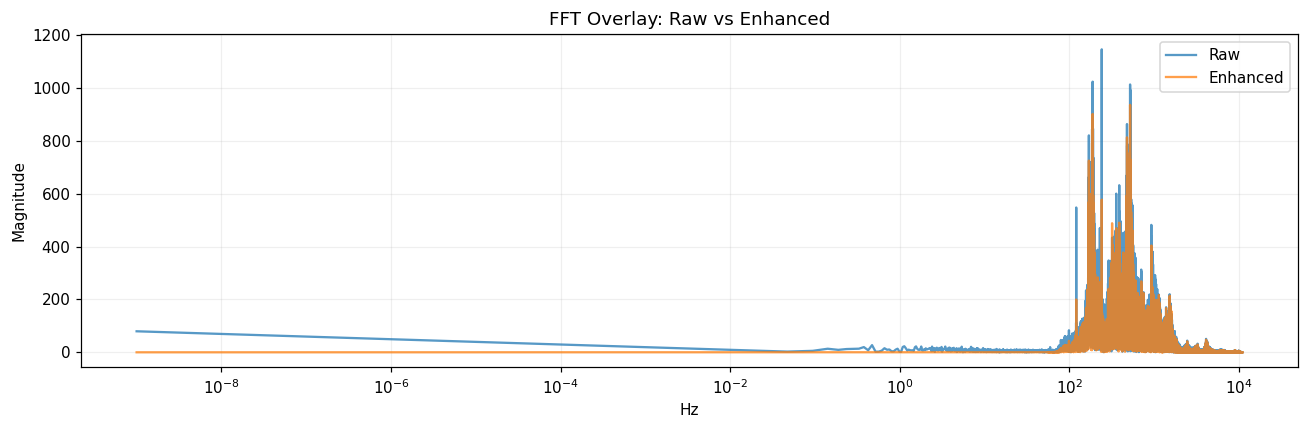

,raw,enhanced,delta
sub_bass_20_60,3.799603e+03,1.732239e+02,-3626.378647
bass_60_250,4.045243e+05,3.318963e+05,-72628.062500
mids_250_4000,3.307539e+06,2.794330e+06,-513208.500000
highs_4000_12000,3.510891e+05,3.017961e+05,-49293.062500


,raw_peak_hz,enh_peak_hz
0,169.313910,184.680451
1,184.680451,187.546992
2,187.546992,189.285714
3,189.285714,476.409774
4,240.084586,513.956767
5,476.409774,515.366541
6,513.956767,518.233083
7,518.233083,528.994361


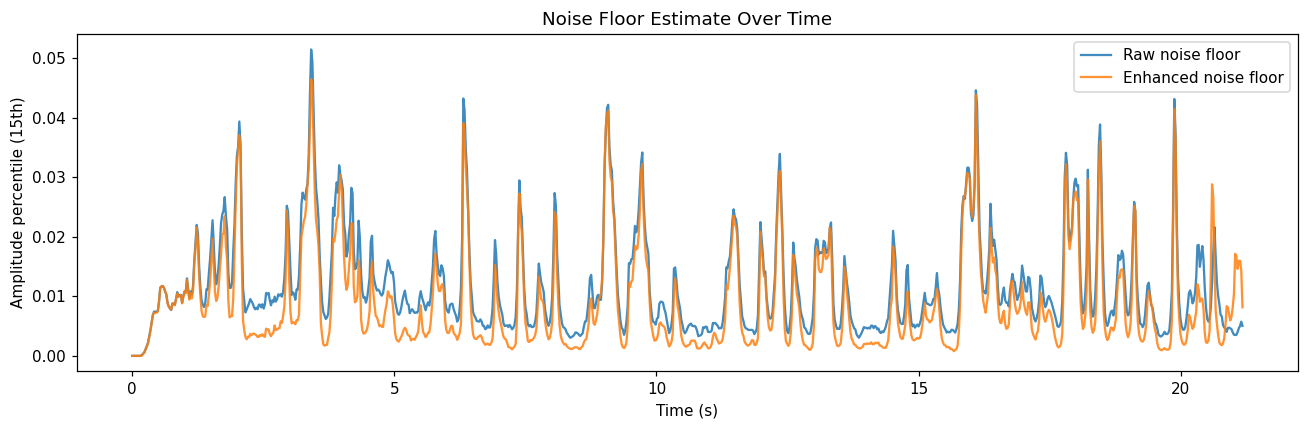

,raw_rms,enh_rms,rms_delta_db,snr_proxy_raw_db,snr_proxy_enh_db,snr_proxy_delta_db,clip_ratio,non_finite_samples
0,0.073825,0.063395,-1.322954,-0.08948,-0.091578,-0.002098,0.0,0


In [13]:
# Before/after waveform
fig_wave = plt.figure(figsize=(12, 6))
ax1 = fig_wave.add_subplot(2, 1, 1)
ax1.plot(audio, linewidth=0.7, label='Raw', color='tab:blue')
ax1.set_title('Raw Waveform')
ax1.set_ylabel('Amplitude')

ax2 = fig_wave.add_subplot(2, 1, 2, sharex=ax1)
ax2.plot(enhanced_audio, linewidth=0.7, label='Enhanced', color='tab:orange')
ax2.set_title('Enhanced Waveform')
ax2.set_xlabel('Samples')
ax2.set_ylabel('Amplitude')

fig_wave.tight_layout()
plt.show()

# Before/after spectrogram
S_enh = np.abs(librosa.stft(enhanced_audio, n_fft=2048, hop_length=512))
S_enh_db = librosa.amplitude_to_db(S_enh, ref=np.max)

fig_spec, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
librosa.display.specshow(S_raw_db, sr=sr, hop_length=512, x_axis='time', y_axis='log', ax=axes[0])
axes[0].set_title('Raw Spectrogram')

librosa.display.specshow(S_enh_db, sr=sr, hop_length=512, x_axis='time', y_axis='log', ax=axes[1])
axes[1].set_title('Enhanced Spectrogram')

fig_spec.tight_layout()
plt.show()

# FFT overlay
fft_freq_enh, fft_mag_enh = compute_fft_magnitude(enhanced_audio, sr)
plt.figure(figsize=(12, 4))
plt.semilogx(fft_freq_raw + 1e-9, fft_mag_raw, label='Raw', alpha=0.75)
plt.semilogx(fft_freq_enh + 1e-9, fft_mag_enh, label='Enhanced', alpha=0.75)
plt.title('FFT Overlay: Raw vs Enhanced')
plt.xlabel('Hz')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

def band_energy(x, sr):
    freq, mag = compute_fft_magnitude(x, sr)
    bands = {
        'sub_bass_20_60': (20, 60),
        'bass_60_250': (60, 250),
        'mids_250_4000': (250, 4000),
        'highs_4000_12000': (4000, 12000),
    }
    out = {}
    for name, (lo, hi) in bands.items():
        mask = (freq >= lo) & (freq < hi)
        out[name] = float(np.sum(mag[mask]))
    return out

band_raw = band_energy(audio, sr)
band_enh = band_energy(enhanced_audio, sr)
band_df = pd.DataFrame([band_raw, band_enh], index=['raw', 'enhanced']).T
band_df['delta'] = band_df['enhanced'] - band_df['raw']
display(band_df)

# Dominant peak tracking
peak_idx_raw, _ = signal.find_peaks(fft_mag_raw, distance=25)
peak_idx_enh, _ = signal.find_peaks(fft_mag_enh, distance=25)

top_raw = peak_idx_raw[np.argsort(fft_mag_raw[peak_idx_raw])[-8:]] if len(peak_idx_raw) else np.array([], dtype=int)
top_enh = peak_idx_enh[np.argsort(fft_mag_enh[peak_idx_enh])[-8:]] if len(peak_idx_enh) else np.array([], dtype=int)

peak_df = pd.DataFrame({
    'raw_peak_hz': np.sort(fft_freq_raw[top_raw]) if len(top_raw) else [],
    'enh_peak_hz': np.sort(fft_freq_enh[top_enh]) if len(top_enh) else [],
})
display(peak_df)

# Noise floor estimate over time windows
def rolling_noise_floor(x, frame=2048, hop=512):
    vals = []
    times = []
    for start in range(0, len(x) - frame + 1, hop):
        seg = x[start:start + frame]
        vals.append(float(np.percentile(np.abs(seg), 15)))
        times.append(start / sr)
    return np.asarray(times), np.asarray(vals)

t_raw, nf_raw = rolling_noise_floor(audio)
t_enh, nf_enh = rolling_noise_floor(enhanced_audio)

plt.figure(figsize=(12, 4))
plt.plot(t_raw, nf_raw, label='Raw noise floor', alpha=0.85)
plt.plot(t_enh, nf_enh, label='Enhanced noise floor', alpha=0.85)
plt.title('Noise Floor Estimate Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude percentile (15th)')
plt.legend()
plt.tight_layout()
plt.show()

# Save key diagnostic figures
fig_wave.savefig(OUTPUT_DIR / 'waveform_before_after.png', bbox_inches='tight')
fig_spec.savefig(OUTPUT_DIR / 'spectrogram_before_after.png', bbox_inches='tight')

metrics_df

,segment_seconds,overlap,snr_proxy_delta_db,clip_ratio,rms_delta_db
0,1.0,0.25,-0.003549,0.0,-1.459390
1,2.0,0.50,-0.002098,0.0,-1.322954
2,4.0,0.50,-0.007582,0.0,-1.244997


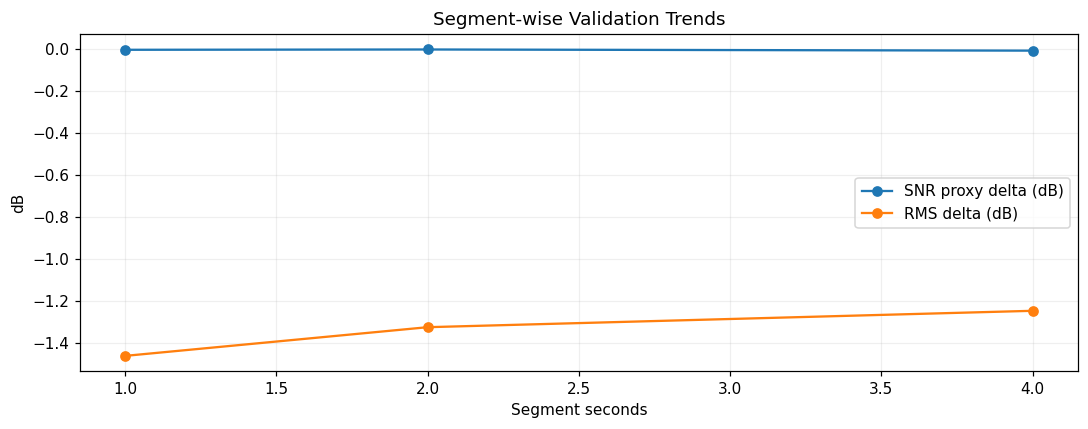

,non_finite_samples_zero,clip_ratio_leq_0_1pct,duration_error_leq_0_5pct,rms_delta_within_plus_minus_6db,snr_proxy_non_decreasing
0,True,True,True,True,False


Numeric gate pass: False


In [14]:
def run_pipeline_for_config(x, sr, segment_seconds, overlap):
    segs, hop = segment_audio(x, sr, segment_seconds=segment_seconds, overlap=overlap)
    enh = []
    for seg in segs:
        y = enhance_segment_classical(seg, sr)
        y = maybe_ml_enhance_segment(y)
        enh.append(y)

    enh = np.asarray(enh, dtype=np.float32)
    out = overlap_add(enh, hop)[:len(x)]
    m = compute_metrics(x, out)
    m['segment_seconds'] = segment_seconds
    m['overlap'] = overlap
    return m

sweep_rows = []
for cfg in VALIDATION_SWEEPS:
    row = run_pipeline_for_config(
        audio,
        sr,
        segment_seconds=cfg['segment_seconds'],
        overlap=cfg['overlap'],
    )
    sweep_rows.append(row)

sweep_df = pd.DataFrame(sweep_rows).sort_values(['segment_seconds', 'overlap']).reset_index(drop=True)
display(sweep_df[['segment_seconds', 'overlap', 'snr_proxy_delta_db', 'clip_ratio', 'rms_delta_db']])

plt.figure(figsize=(10, 4))
plt.plot(sweep_df['segment_seconds'], sweep_df['snr_proxy_delta_db'], marker='o', label='SNR proxy delta (dB)')
plt.plot(sweep_df['segment_seconds'], sweep_df['rms_delta_db'], marker='o', label='RMS delta (dB)')
plt.title('Segment-wise Validation Trends')
plt.xlabel('Segment seconds')
plt.ylabel('dB')
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# Threshold + visual review support
duration_error_ratio = abs(len(enhanced_audio) - len(audio)) / max(1, len(audio))
pass_checks = {
    'non_finite_samples_zero': int(metrics['non_finite_samples']) == 0,
    'clip_ratio_leq_0_1pct': float(metrics['clip_ratio']) <= 0.001,
    'duration_error_leq_0_5pct': float(duration_error_ratio) <= 0.005,
    'rms_delta_within_plus_minus_6db': abs(float(metrics['rms_delta_db'])) <= 6.0,
    'snr_proxy_non_decreasing': float(metrics['snr_proxy_delta_db']) >= 0.0,
}

pass_df = pd.DataFrame([pass_checks])
display(pass_df)
print('Numeric gate pass:', bool(pass_df.all(axis=1).iloc[0]))

In [15]:
sf.write(OUTPUT_PATH, enhanced_audio, sr)
metrics_df.to_csv(OUTPUT_DIR / 'enhancement_metrics.csv', index=False)
sweep_df.to_csv(OUTPUT_DIR / 'validation_sweeps.csv', index=False)
band_df.to_csv(OUTPUT_DIR / 'band_energy_summary.csv')

print('Saved enhanced audio to:', OUTPUT_PATH)
print('Saved metrics to:', OUTPUT_DIR / 'enhancement_metrics.csv')
print('Saved validation sweeps to:', OUTPUT_DIR / 'validation_sweeps.csv')
print('Saved band summary to:', OUTPUT_DIR / 'band_energy_summary.csv')

Saved enhanced audio to: c:\Users\Windows User\NMR-Project\audio_visuals\outputs\enhanced_podcast.wav
Saved metrics to: c:\Users\Windows User\NMR-Project\audio_visuals\outputs\enhancement_metrics.csv
Saved validation sweeps to: c:\Users\Windows User\NMR-Project\audio_visuals\outputs\validation_sweeps.csv
Saved band summary to: c:\Users\Windows User\NMR-Project\audio_visuals\outputs\band_energy_summary.csv


In [ ]:

print("\n" + "="*70)
print("ENHANCEMENT COMPLETE")
print("="*70)
print(f"\n✓ Input audio: {duration:.1f} seconds")
print(f"✓ Enhanced audio written to: {OUTPUT_PATH}")
print(f"✓ Diagnostics written to: {OUTPUT_DIR}\n")

# Summary for non-technical users
snr_delta = float(metrics['snr_proxy_delta_db'])
rms_delta = float(metrics['rms_delta_db'])
clip_safe = float(metrics['clip_ratio']) <= 0.001
no_artifacts = int(metrics['non_finite_samples']) == 0

print("Quality Summary:")
print("-" * 70)
if snr_delta > 0.5:
    print(f"  • Noise reduction: STRONG (+{snr_delta:.2f} dB)")
elif snr_delta > 0:
    print(f"  • Noise reduction: MODEST (+{snr_delta:.2f} dB)")
else:
    print(f"  • Noise reduction: MINIMAL or N/A ({snr_delta:.2f} dB)")
    print("    (This is normal for already-clean audio; test with a noisier recording)")

print(f"  • Volume change: {abs(rms_delta):.2f} dB {'↓' if rms_delta < 0 else '↑'} (goal: ±6 dB max)")
print(f"  • Clipping safe: {'YES ✓' if clip_safe else 'NO ✗ (audio distorted)'}")
print(f"  • Artifacts: {'None ✓' if no_artifacts else 'DETECTED ✗'}")
print("-" * 70)

sweep_variance = sweep_df['snr_proxy_delta_db'].std()
robust = sweep_variance < 0.5
print(f"\nRobustness: Metrics variance = {sweep_variance:.3f} dB")
print(f"  → {'STABLE ✓ (test with different audio)' if robust else 'VARIABLE (consider audio quality)'}")

print("\nNext steps:")
print("  1. Listen to: audio_visuals/outputs/enhanced_podcast.wav")
print("  2. View spectrogram: audio_visuals/outputs/spectrogram_before_after.png")
print("  3. Check metrics: audio_visuals/outputs/enhancement_metrics.csv")
print("  4. Ready to upload to YouTube/podcast platform!")
print("="*70 + "\n")